# 📊 Ollama Hardware Benchmark & Optimization Suite

**Objective:**
This notebook serves two primary purposes for the RAG pipeline:
1.  **Model Selection:** Identify which local LLMs run most efficiently on your specific hardware (e.g., Apple Silicon M-Series). It categorizes models by size and filters for a minimum token-per-second (t/s) threshold.
2.  **Throughput Optimization (Advanced):** Determine the optimal `OLLAMA_NUM_PARALLEL` setting to maximize concurrency during the evaluation phase (Evolutionary HPO).

> **⚠️ Critical Disclaimer regarding DeepSeek-V3 - OCR Model:**
> There is a known issue with certain specific model versions, such as `deepseek:ocr` 
, which may cause the Ollama API to hang or crash during high-frequency benchmarking.
> **Recommendation:** Please ensure these specific models are uninstalled (`ollama rm deepseek:ocr`) or explicitly excluded before running this benchmark to prevent runtime errors.

---



In [1]:
### 1. Initialization and Server Check
import subprocess
import time
import ollama
import pandas as pd
import re
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage
import matplotlib.pyplot as plt

# Check if Ollama is running; start if necessary
try:
    ollama.list() # Ping the server
    print("✅ Ollama is already running.")
except:
    print("🔄 Starting Ollama server...")
    # Start server and suppress logs to keep notebook clean
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(5) # Allow warm-up time
    print("✅ Ollama started.")

🔄 Starting Ollama server...
✅ Ollama started.


### 2. Metadata Extraction
We retrieve the technical specifications (parameter count, quantization level, and binary size) for all locally available models. This establishes the baseline for our "Size vs. Speed" analysis.

In [2]:
print("⏳ Retrieving model metadata...")

# Fetch full model list
raw_models = ollama.list().models

# Extract specific details using list comprehensions
models = [m.model for m in raw_models]
# Convert size to Gigabytes (GB)
models_size = [round(m.size / 1e9, 2) for m in raw_models]
# Extract parameter strings (e.g., "7B")
models_parameter_size = [m.details.parameter_size for m in raw_models]
# Extract quantization method (e.g., "Q4_K_M")
models_quantization = [m.details.quantization_level for m in raw_models]

print(f"✅ Found {len(models)} models locally.")

⏳ Retrieving model metadata...
✅ Found 58 models locally.


### 3. Inference Latency Benchmark
This section iterates through every model to measure generation speed. We use standardized prompts to calculate the average Tokens Per Second (t/s). Models that do not support chat interfaces (e.g., pure embedding models) are automatically detected and skipped.

In [ ]:
# 1. Configuration: Standard prompts for testing generation speed
prompts = [
    """Describe a scene of a beach at sunset in three sentences, but do not use the words "sun", "sea", or "sky" """,
    """Write the word "strawberry" exactly five times, each on a separate line, and do not include any other text."""
]

results = []

print(f"🚀 Starting Benchmark for: {models}\n")

# 2. Benchmark Loop
for i in range(len(models)):
    # Get current model details
    model_name = models[i]
    size_gb = models_size[i]
    param_str = models_parameter_size[i]
    quant_level = models_quantization[i]
    
    print(f"--- Testing: {model_name} ({param_str} | {quant_level} | {size_gb} GB) ---")
    
    # Initialize LangChain wrapper
    llm = ChatOllama(model=model_name, temperature=0)
    
    skip_model = False # Flag to skip broken/incompatible models

    for prompt in prompts:
        if skip_model: break 

        try:
            # Execute Inference
            response = llm.invoke([HumanMessage(content=prompt)])
            meta = response.response_metadata
            
            # 3. Calculate Metrics
            load_time = meta.get('load_duration', 0) / 1e9
            eval_count = meta.get('eval_count', 0)
            eval_duration = meta.get('eval_duration', 1) / 1e9
            
            # Calculate Speed (Tokens / Second)
            tokens_per_sec = eval_count / eval_duration if eval_duration > 0 else 0
            
            # Efficiency Score (Speed * Size) -> Heuristic for "Performance density"
            score = tokens_per_sec * size_gb 
            
            results.append({
                "Model": model_name,
                "Size (GB)": size_gb,
                "Params": param_str,
                "Quantization": quant_level,
                "Speed (t/s)": round(tokens_per_sec, 2),
                "Score": round(score, 2)
            })
            print(f"   > Speed: {round(tokens_per_sec, 2)} t/s")
            
        except Exception as e:
            # Error Handling: Detect non-chat models
            err_msg = str(e).lower()
            if "does not support chat" in err_msg or "status code: 400" in err_msg:
                print(f"   ⚠️ Skipped: '{model_name}' appears to be an embedding or non-chat model.")
                skip_model = True 
            else:
                print(f"   ❌ Error: {e}")

    # Clean up memory
    try: subprocess.Popen(['ollama', 'stop', model_name]) 
    except: pass

# 4. Save Results
if results:
    df = pd.DataFrame(results)
    # Save raw results
    df.to_csv('ollama-benchmark.csv', index=False)
    print("\n✅ Benchmark complete. Results saved.")
else:
    print("\n❌ No results collected.")

## 4. Analysis and Selection
We aggregate the results to find the most efficient models.
### Filtering: We remove duplicates and filter out models slower than 55 t/s (threshold for acceptable interactive speed).

Clustering: Models are grouped into Tiny, Small, and Medium based on memory usage to identify the best performers in each class.

Selected Models: 21


,Model,Size (GB),Speed (t/s),Score,Cluster
30,qwen2.5-coder:0.5b-instruct,0.40,239.000,95.600,Tiny
18,granite4:350m,0.71,229.090,162.655,Tiny
3,gemma3:1b,0.82,134.480,110.270,Tiny
31,qwen2.5-coder:1.5b-instruct,0.99,151.180,149.665,Tiny
0,deepseek-r1:1.5b,1.12,147.110,164.770,Tiny
45,qwen3:1.7b,1.36,115.895,157.620,Tiny
12,granite3.1-moe:1b,1.42,184.805,262.420,Tiny
14,granite3.3:2b,1.55,105.035,162.805,Small
37,qwen3-vl:2b-thinking,1.89,120.325,227.415,Small
36,qwen3-vl:2b-instruct,1.89,124.545,235.390,Small



--- Copy this list to config.py ---
"model_name": ['qwen2.5-coder:0.5b-instruct', 'granite4:350m', 'gemma3:1b', 'qwen2.5-coder:1.5b-instruct', 'deepseek-r1:1.5b', 'qwen3:1.7b', 'granite3.1-moe:1b', 'granite3.3:2b', 'qwen3-vl:2b-thinking', 'qwen3-vl:2b-instruct', 'qwen2.5-coder:3b-instruct', 'granite3.1-moe:3b', 'granite4:micro', 'phi4-mini:3.8b-q4_K_M', 'qwen2.5vl:3b', 'gemma3:4b', 'granite4:tiny-h', 'gemma3n:e2b', 'qwen3-coder:30b', 'qwen3-vl:30b-a3b-thinking', 'qwen3-vl:30b-a3b-instruct']


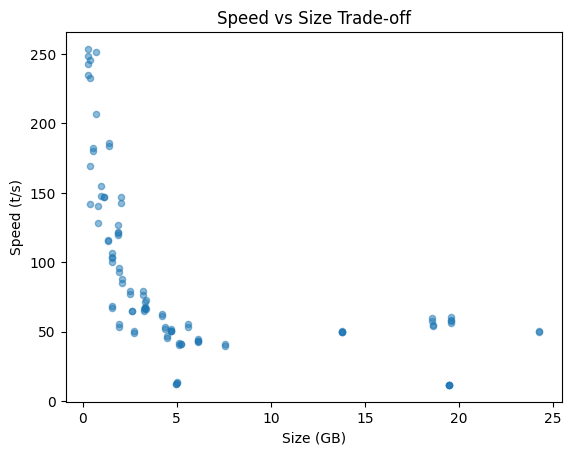

In [8]:

import pandas as pd
import matplotlib.pyplot as plt


df_sorted = pd.read_csv('../results/experiments/ollama-benchmark.csv')

# --- FIX: Standardize Column Names ---
# Handles legacy CSVs where the column might be named "Modell" (German)
if 'Modell' in df_sorted.columns:
    df_sorted = df_sorted.rename(columns={'Modell': 'Model'})

# --- STEP 1: Aggregate Duplicates ---
# Group by Model name and take the mean of numerical values (averaging the prompts)
df_unique = df_sorted.groupby('Model', as_index=False).mean(numeric_only=True)

# 1. Filter: Minimum Speed Requirement (> 55 t/s)
df_final = df_unique[df_unique['Speed (t/s)'].round(0) >= 55].copy()

# Safety Check: Ensure we have enough models
if len(df_final) < 21:
    print(f"⚠️ Warning: Only {len(df_final)} models remain after filtering. Using all available.")
    picks = df_final 
else:
    # 2. Clustering: Divide into size categories (Tiny, Small, Medium)
    df_final['Cluster'] = pd.qcut(df_final['Size (GB)'], q=3, labels=['Tiny', 'Small', 'Medium'])

    # 3. Selection: Pick Top 7 by Score per Cluster
    picks = (df_final
             .sort_values('Score', ascending=False)
             .groupby('Cluster', observed=True)
             .head(7)
            )

# --- DISPLAY RESULTS ---
picks_sorted = picks.sort_values('Size (GB)')
print(f"Selected Models: {len(picks_sorted)}")
display(picks_sorted[['Model', 'Size (GB)', 'Speed (t/s)', 'Score', 'Cluster']])

# --- CONFIG EXPORT ---
print("\n--- Copy this list to config.py ---")
print(f'"model_name": {picks_sorted["Model"].tolist()}')

# Visualizing the Trade-off
df_sorted.plot.scatter(y='Speed (t/s)', x='Size (GB)', alpha=0.5, title="Speed vs Size Trade-off")
plt.show()

## 5. Advanced Parallelization Optimization

Use Case: This step is optional but highly recommended for the "Judge Model" (the model used to evaluate answers). RAG evaluation involves sending hundreds of prompts simultaneously. Optimizing OLLAMA_NUM_PARALLEL can drastically reduce the total runtime of your genetic algorithm.

### Configuration Guidelines:

Select the Judge Model: Set MODEL to the model you intend to use for evaluation (e.g., qwen3-coder:30b).
GPU Core Heuristic: A good starting point for PARALLEL_RANGE is often related to your GPU core count.

⚠️ System Warning: This script explicitly kills (pkill) and restarts the Ollama server process to apply environment variables. Ensure no other critical Ollama tasks are running.

In [ ]:
import time
import subprocess
import matplotlib.pyplot as plt
from langchain_ollama import ChatOllama

# ================= USER CONFIGURATION =================
# Recommendation: Use your intended Judge Model here
MODEL = "qwen3-coder:30b"   
REQUESTS = 100          # Number of concurrent requests to simulate
PARALLEL_RANGE = [2, 4, 8, 16, 32, 64] # Sweep range

# Create a batch of dummy RAG-evaluation prompts
prompts = [f"""### Instruction:
                You are a concise assistant. Answer the Question strictly using only the provided Context.
                ### Question:
                Explain thermodynamics simply. {i}
                ### Answer:
                """ for i in range(REQUESTS)]

# ================= HELPER FUNCTIONS =================

def restart_server(n_parallel):
    """
    Hard restart of the Ollama server to apply OLLAMA_NUM_PARALLEL.
    """
    # 1. Kill existing process
    subprocess.run("pkill -f ollama", shell=True, stderr=subprocess.DEVNULL)
    time.sleep(1) 
    
    # 2. Start with new environment variables
    # We set MAX_QUEUE high to prevent dropped requests during batching
    cmd = (f"export OLLAMA_NUM_PARALLEL={n_parallel} && "
           f"export OLLAMA_MAX_QUEUE={REQUESTS*2} && "
           "ollama serve")
    subprocess.Popen(cmd, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
    # 3. Wait for readiness (Ping loop)
    print(f"   🔄 Restarting with NP={n_parallel}...", end="", flush=True)
    tester = ChatOllama(model=MODEL)
    for _ in range(30):
        try:
            tester.invoke("ping")
            print(" ✅ Ready")
            return
        except:
            time.sleep(1)
    print(" ❌ Server failed to start")

def run_simple_batch():
    """
    Executes a batch of requests and measures total throughput.
    """
    chat = ChatOllama(model=MODEL, temperature=0)
    
    t0 = time.time()
    # langChain's .batch() handles threading internally
    results = chat.batch(prompts, config={"max_concurrency": REQUESTS})
    total_time = time.time() - t0
    
    # Extract latencies
    latencies = [r.response_metadata.get('total_duration', 0) / 1e9 for r in results]
    return total_time, latencies

# ================= MAIN EXECUTION =================

tps_list = []
labels = []
box_data = []

print(f"--- 🚀 Starting Parallel Optimization for {MODEL} ---")

for np in PARALLEL_RANGE:
    restart_server(np)
    
    # Warmup inference to load model into RAM/VRAM
    try: ChatOllama(model=MODEL).invoke("warmup")
    except: pass

    # Run Measurement
    duration, latencies = run_simple_batch()
    
    # Calculate Throughput (Requests per Second)
    tps = REQUESTS / duration
    tps_list.append(tps)
    labels.append(str(np))
    box_data.append(latencies)
    
    print(f"   NP={np:02d} | Time: {duration:.2f}s | TPS: {tps:.2f}")

# ================= VISUALIZATION =================
if tps_list:
    best_np = labels[tps_list.index(max(tps_list))]
    print(f"\n🏆 OPTIMAL SETTING: OLLAMA_NUM_PARALLEL = {best_np}")

    plt.figure(figsize=(10, 6))
    
    # Boxplot for Latency distribution
    plt.boxplot(box_data, labels=labels, patch_artist=True)
    plt.ylabel('Latency per Request (s)')
    plt.xlabel('OLLAMA_NUM_PARALLEL Setting')
    
    # Line plot for Throughput (TPS)
    ax2 = plt.gca().twinx()
    ax2.plot(ax2.get_xticks(), tps_list, color='red', marker='o', linewidth=2, label='Throughput')
    ax2.set_ylabel('Throughput (TPS)', color='red')
    
    plt.title(f'Parallelization Sweep: {MODEL}')
    plt.grid(True, alpha=0.3)
    plt.show()

### 6. Cleanup
Finally, we stop the benchmark server.

In [ ]:
import subprocess
import time

print("🛑 Stopping Benchmark Server...")
subprocess.Popen(["pkill", "-f", "ollama serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(2)